# Chapter 10: Options and Futures

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Call and put payoffs
2. Black-Scholes-Merton valuation
3. Put-call parity
4. Implied volatility and volatility smiles
5. Trading strategies and Greeks
6. Currency forward arbitrage

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 10.1 Option Payoff and Profit

Payoff excludes the initial premium; profit includes it. Buyer and seller positions have opposite terminal profit.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [1]:
import numpy as np

terminal_prices = np.array([30, 40, 50, 60, 70], dtype=float)
strike, call_premium, put_premium = 50, 4.5, 3.5

call_payoff = np.maximum(terminal_prices - strike, 0)
put_payoff = np.maximum(strike - terminal_prices, 0)
call_profit = call_payoff - call_premium
put_profit = put_payoff - put_premium

for price, call, put in zip(terminal_prices, call_profit, put_profit):
    print(f"S_T={price:.0f}: long-call profit={call:.2f}, long-put profit={put:.2f}")


S_T=30: long-call profit=-4.50, long-put profit=16.50
S_T=40: long-call profit=-4.50, long-put profit=6.50
S_T=50: long-call profit=-4.50, long-put profit=-3.50
S_T=60: long-call profit=5.50, long-put profit=-3.50
S_T=70: long-call profit=15.50, long-put profit=-3.50


**Result interpretation.** A call benefits from prices above the strike; a put benefits from prices below the strike.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

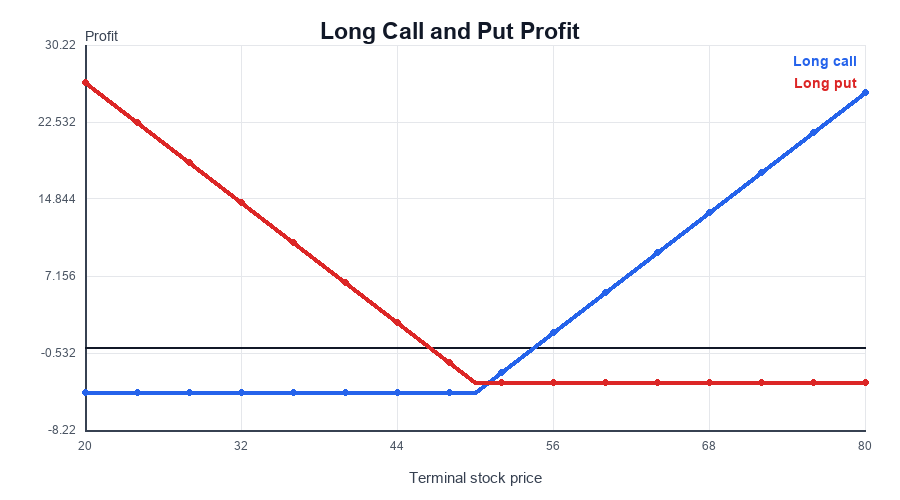


## 10.2 Black-Scholes-Merton and Put-Call Parity

European call and put prices should satisfy C + K exp(-rT) = S + P when assumptions and inputs are consistent.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [2]:
from math import exp, log, sqrt
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    call = S * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)
    put = K * exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call, put

S, K, T, r, sigma = 40, 40, 0.5, 0.01, 0.20
call, put = black_scholes(S, K, T, r, sigma)

# 两个复制组合的现值应当相同
left = call + K * exp(-r * T)
right = S + put
print("Call =", round(call, 4), "Put =", round(put, 4))
print("Parity difference =", round(left - right, 10))


Call = 2.3504 Put = 2.1509
Parity difference = 0.0


**Result interpretation.** The parity difference is numerically zero, which checks both formulas at once.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 10.3 Implied Volatility

Implied volatility reverses an option-pricing model: find sigma that reproduces the observed market price.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [3]:
from math import exp, log, sqrt
from scipy.optimize import brentq
from scipy.stats import norm

def call_price(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)

def implied_volatility(S, K, T, r, market_price):
    # 根是“模型价格 - 市场价格 = 0”
    objective = lambda sigma: call_price(S, K, T, r, sigma) - market_price
    return brentq(objective, 1e-6, 5.0)

S, T, r = 100, 0.5, 0.02
quotes = [(90, 12.80), (100, 6.00), (110, 3.15)]
for strike, market_price in quotes:
    iv = implied_volatility(S, strike, T, r, market_price)
    print(f"K={strike}: implied volatility={iv:.2%}")


K=90: implied volatility=21.77%
K=100: implied volatility=19.57%
K=110: implied volatility=22.71%


**Result interpretation.** Different implied volatilities across strikes produce the volatility-smile or skew pattern.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

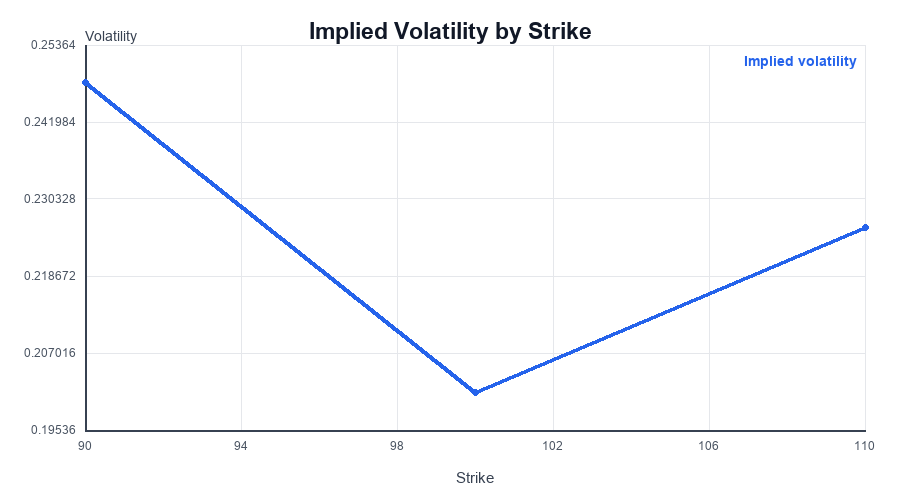


## 10.4 Option Strategies

A straddle buys a call and a put at the same strike; a covered call combines stock ownership with a short call.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [4]:
import numpy as np

terminal_prices = np.arange(30, 71, 10)
strike, call_premium, put_premium, stock_price = 50, 4.5, 3.5, 50

# Straddle 需要价格大幅向任一方向变化
straddle = np.maximum(terminal_prices - strike, 0) + np.maximum(strike - terminal_prices, 0) - call_premium - put_premium

# Covered call 的上涨收益被执行价封顶
covered_call = terminal_prices - stock_price - np.maximum(terminal_prices - strike, 0) + call_premium

for price, s_profit, c_profit in zip(terminal_prices, straddle, covered_call):
    print(f"S_T={price}: straddle={s_profit:.2f}, covered call={c_profit:.2f}")


S_T=30: straddle=12.00, covered call=-15.50
S_T=40: straddle=2.00, covered call=-5.50
S_T=50: straddle=-8.00, covered call=4.50
S_T=60: straddle=2.00, covered call=4.50
S_T=70: straddle=12.00, covered call=4.50


**Result interpretation.** The straddle is a volatility position, whereas the covered call exchanges upside potential for premium income.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 10.5 Delta and Gamma

Delta is the first derivative of option value with respect to stock price; gamma is the second derivative.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [5]:
from math import exp, log, sqrt
from scipy.stats import norm

def call_price(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)

S, K, T, r, sigma = 40, 40, 0.5, 0.01, 0.20
d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S * sigma * sqrt(T))

bump = 0.01
# 中心差分用 S+h、S、S-h 近似二阶导数
numerical_gamma = (
    call_price(S + bump, K, T, r, sigma)
    - 2 * call_price(S, K, T, r, sigma)
    + call_price(S - bump, K, T, r, sigma)
) / bump**2

print("Delta =", round(delta, 6))
print("Closed-form gamma =", round(gamma, 6))
print("Numerical gamma =", round(numerical_gamma, 6))


Delta = 0.542235
Closed-form gamma = 0.070128
Numerical gamma = 0.070128


**Result interpretation.** The analytical and finite-difference gamma values should agree closely.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 10.6 Currency Forward No-Arbitrage

Covered interest parity links spot and forward exchange rates through domestic and foreign interest rates.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [6]:
from math import exp

spot = 1.25
domestic_rate = 0.01
foreign_rate = 0.02
T = 3 / 12
market_forward = 1.26

# 连续复利下的无套利远期汇率
fair_forward = spot * exp((domestic_rate - foreign_rate) * T)
mispricing = market_forward - fair_forward

print("Fair forward =", round(fair_forward, 6))
print("Market minus fair =", round(mispricing, 6))


Fair forward = 1.246879
Market minus fair = 0.013121


**Result interpretation.** A market forward above the covered-interest-parity value indicates the direction of a potential arbitrage before transaction costs.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
